
<b><h2>Pillar 5: Capstone Project</h2></b>

<p>
Submitted by: <b>Darwin A. Nepomuceno</b>
</p>
<p>
<b>Post Graduate Diploma in Artificial Intelligence and Machine Learning</b>
</p>

___


# 🏥 **PHASE 03 | CTG — Baseline & Cost-Sensitive Modeling**

## **Goal: Build models optimized for **Clinical Cost** rather than Accuracy.**

> In fetal monitoring, a missed Abnormal case (False Negative) is far more dangerous
> than a false alarm (False Positive). We encode this asymmetry directly into training.

**Cost Function:**
$$\text{Cost} = (1 \times FP) + (10 \times FN)$$

| Step | What |
|------|------|
| 1 | Reproduce clean data from Phase 01 & 2 |
| 2 | Baseline models on raw imbalanced data |
| 3 | Advanced models with SMOTE / class_weight strategies |
| 4 | Custom cost scorer + Optuna hyperparameter tuning |
| 5 | Final comparison & best model selection |

## 0 · Imports & Setup

In [1]:
import pickle
import warnings
from typing import cast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    make_scorer,
)


import xgboost as xgb
import lightgbm as lgb
import optuna

from sklearn.base import BaseEstimator


print("Libraries loaded ✓  (data loading handled via Phase 02 pickle — see Section 1)")

Libraries loaded ✓  (data loading handled via Phase 02 pickle — see Section 1)


In [2]:

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PALETTE = {0: "#2196F3", 1: "#F44336"}
LABEL = {0: "Normal", 1: "Abnormal"}
SEED = 42

## 1 · Load Preprocessed Data from Phase 02

> Loads `ctg_preprocessed.pkl`, produced by the Phase 02 notebook's final cell.
> This guarantees the exact same train/test split, fitted `StandardScaler`,
> and SMOTE/ADASYN-resampled arrays — no risk of preprocessing logic drifting
> between notebooks. **Run Phase 02 first** if this file doesn't exist yet.

In [3]:
# ── Load preprocessed data from Phase 02 ──────────────────────────────────────
# Loads the EXACT same train/test split, fitted scaler, and resampled arrays
# produced in Phase 02 — guarantees byte-identical data with zero risk of the
# split/scaling logic drifting between notebooks.


PICKLE_PATH = "../04 misc/ctg_preprocessed.pkl"

try:
    with open(PICKLE_PATH, "rb") as f:
        prep = pickle.load(f)
except FileNotFoundError as e:
    raise FileNotFoundError(
        f"'{PICKLE_PATH}' not found. Run the Phase 02 preprocessing notebook "
        f"first — its final cell saves this pickle file in the same directory."
    ) from e

# ── Unpack ────────────────────────────────────────────────────────────────────
X_train_scaled = prep["X_train_scaled"]
y_train = prep["y_train"]
X_train_smote = prep["X_train_smote"]
y_train_smote = prep["y_train_smote"]
X_train_adasyn = prep["X_train_adasyn"]
y_train_adasyn = prep["y_train_adasyn"]
class_weight_dict = prep["class_weight_dict"]
X_test_scaled = prep["X_test_scaled"]
y_test = prep["y_test"]
FEATURES = prep["feature_names"]
scaler = prep["scaler"]

# scale_pos_weight isn't stored directly in the pickle — derive it from y_train
# (this is a cheap, deterministic calculation, not a re-derivation of the split)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Wrap y_train / y_test as pandas Series for compatibility with downstream code
# that calls methods like .values (sklearn metrics accept arrays or Series either way)

y_train = pd.Series(y_train, name="target")
y_test = pd.Series(y_test, name="target")

print(f"Loaded from {PICKLE_PATH}")
print(f"X_train_scaled : {X_train_scaled.shape}")
print(f"X_test_scaled  : {X_test_scaled.shape}")
print(f"X_train_smote  : {X_train_smote.shape}")
print(f"Feature count  : {len(FEATURES)}")
print(f"Class weights  : {class_weight_dict}")
print(f"scale_pos_weight (derived from y_train) : {scale_pos_weight:.4f}")

Loaded from ../04 misc/ctg_preprocessed.pkl
X_train_scaled : (1691, 21)
X_test_scaled  : (423, 21)
X_train_smote  : (2636, 21)
Feature count  : 21
Class weights  : {np.int64(0): np.float64(0.6415022761760243), np.int64(1): np.float64(2.266756032171582)}
scale_pos_weight (derived from y_train) : 3.5335


## 2 · Custom Clinical Cost Metric

$$\text{Cost} = (1 \times FP) + (10 \times FN)$$

- **FN weight = 10** — missing a distressed fetus may cause irreversible harm.
- **FP weight = 1** — unnecessary intervention is costly but recoverable.

The scorer returns a **negative** cost so sklearn (which maximises) finds the minimum cost.

In [4]:
def compute_cost(y_true, y_pred):
    """Returns raw clinical cost: FP*1 + FN*10. Lower is better."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return int(fp * 1 + fn * 10)

In [5]:
def cost_scorer_fn(y_true, y_pred):
    """Sklearn scorer: negated cost so higher = better (sklearn maximises)."""
    return -1 * compute_cost(y_true, y_pred)


custom_score = make_scorer(cost_scorer_fn, greater_is_better=False)

In [6]:
# Quick sanity check
_y_true = np.array([0, 0, 1, 1, 1])
_y_pred = np.array([0, 1, 0, 0, 1])  # 1 FP, 2 FN → cost = 1 + 20 = 21
assert compute_cost(_y_true, _y_pred) == 21, "Cost function check failed"
print("Cost function verified ✓")
print("  1 FP + 2 FN  →  expected 21  →  got", compute_cost(_y_true, _y_pred))

Cost function verified ✓
  1 FP + 2 FN  →  expected 21  →  got 21


## 3 · Evaluation Helper

In [7]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """
    Fit model, predict on test set, return metrics dict + fitted model + predictions.
    """
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    cost = int(fp * 1 + fn * 10)

    metrics = {
        "Model": name,
        "Accuracy": round(accuracy_score(y_te, y_pred), 4),
        "Precision": round(precision_score(y_te, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_te, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_te, y_pred, zero_division=0), 4),
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "Cost (FP+10×FN)": cost,
    }
    return metrics, model, y_pred


all_results = []  # accumulates dicts from every model
print("evaluate_model() helper defined ✓")

evaluate_model() helper defined ✓


---
## 4 · Baseline Models (Raw Imbalanced Data)
**What it does :**  Trained on **X_train_scaled** (no SMOTE, no class_weight).
- Expected: high Accuracy but poor Recall on the Abnormal class.

In [8]:
# ── Logistic Regression baseline ──────────────────────────────────────────────
lr_baseline = LogisticRegression(max_iter=1000, random_state=SEED)
r_lr, lr_fit, pred_lr = evaluate_model(
    "LR (baseline)", lr_baseline, X_train_scaled, y_train, X_test_scaled, y_test
)
all_results.append(r_lr)

print("Logistic Regression (Baseline)")
print("=" * 40)
for k, v in r_lr.items():
    print(f"  {k:<20} : {v}")
print()
print(classification_report(y_test, pred_lr, target_names=["Normal", "Abnormal"]))

Logistic Regression (Baseline)
  Model                : LR (baseline)
  Accuracy             : 0.9054
  Precision            : 0.7978
  Recall               : 0.7634
  F1                   : 0.7802
  TP                   : 71
  FP                   : 18
  TN                   : 312
  FN                   : 22
  Cost (FP+10×FN)      : 238

              precision    recall  f1-score   support

      Normal       0.93      0.95      0.94       330
    Abnormal       0.80      0.76      0.78        93

    accuracy                           0.91       423
   macro avg       0.87      0.85      0.86       423
weighted avg       0.90      0.91      0.90       423



In [9]:
# ── Decision Tree baseline ────────────────────────────────────────────────────
dt_baseline = DecisionTreeClassifier(random_state=SEED)
r_dt, dt_fit, pred_dt = evaluate_model(
    "DT (baseline)", dt_baseline, X_train_scaled, y_train, X_test_scaled, y_test
)
all_results.append(r_dt)

print("Decision Tree (Baseline)")
print("=" * 40)
for k, v in r_dt.items():
    print(f"  {k:<20} : {v}")
print()
print(classification_report(y_test, pred_dt, target_names=["Normal", "Abnormal"]))

Decision Tree (Baseline)
  Model                : DT (baseline)
  Accuracy             : 0.9433
  Precision            : 0.8876
  Recall               : 0.8495
  F1                   : 0.8681
  TP                   : 79
  FP                   : 10
  TN                   : 320
  FN                   : 14
  Cost (FP+10×FN)      : 150

              precision    recall  f1-score   support

      Normal       0.96      0.97      0.96       330
    Abnormal       0.89      0.85      0.87        93

    accuracy                           0.94       423
   macro avg       0.92      0.91      0.92       423
weighted avg       0.94      0.94      0.94       423



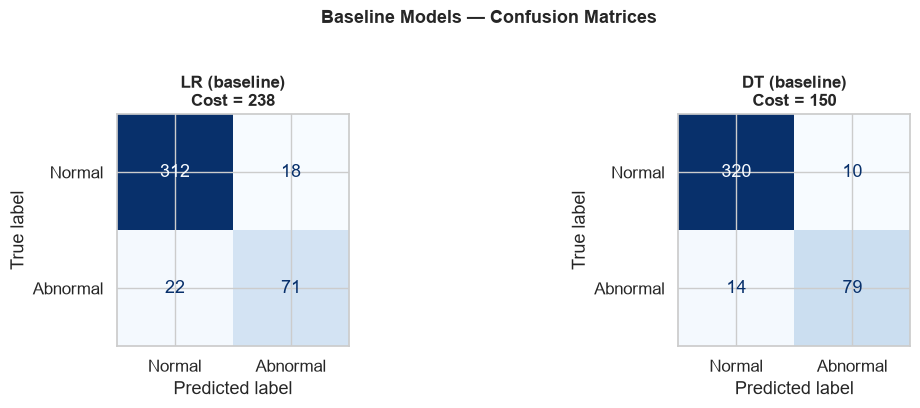

In [10]:
# ── Confusion matrix side-by-side ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, pred) in zip(
    axes, [("LR (baseline)", pred_lr), ("DT (baseline)", pred_dt)]
):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Abnormal"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(
        f"{name}\nCost = {compute_cost(y_test, pred)}", fontsize=12, fontweight="bold"
    )
plt.suptitle(
    "Baseline Models — Confusion Matrices", fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

---
## 5 · Advanced Models

- **Strategy 1** — Train on SMOTE-augmented data.
- **Strategy 2** — Train on raw data with `class_weight='balanced'` or `scale_pos_weight`.

### 5a · Random Forest

In [11]:
# Strategy 1: SMOTE
rf_smote = RandomForestClassifier(n_estimators=100, random_state=SEED)
r_rf_smote, _, pred_rf_smote = evaluate_model(
    "RF (SMOTE)", rf_smote, X_train_smote, y_train_smote, X_test_scaled, y_test
)
all_results.append(r_rf_smote)

# Strategy 2: class_weight
rf_cw = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", random_state=SEED
)
r_rf_cw, _, pred_rf_cw = evaluate_model(
    "RF (class_weight)", rf_cw, X_train_scaled, y_train, X_test_scaled, y_test
)
all_results.append(r_rf_cw)

print(
    f"RF (SMOTE)         → Recall: {r_rf_smote['Recall']}  Cost: {r_rf_smote['Cost (FP+10×FN)']}"
)
print(
    f"RF (class_weight)  → Recall: {r_rf_cw['Recall']}  Cost: {r_rf_cw['Cost (FP+10×FN)']}"
)

RF (SMOTE)         → Recall: 0.8817  Cost: 114
RF (class_weight)  → Recall: 0.8817  Cost: 117


### 5b · XGBoost

In [12]:
# Strategy 1: SMOTE
xgb_smote = xgb.XGBClassifier(
    n_estimators=100, eval_metric="logloss", verbosity=0, random_state=SEED
)
r_xgb_smote, _, pred_xgb_smote = evaluate_model(
    "XGB (SMOTE)", xgb_smote, X_train_smote, y_train_smote, X_test_scaled, y_test
)
all_results.append(r_xgb_smote)

# Strategy 2: scale_pos_weight
xgb_spw = xgb.XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    verbosity=0,
    random_state=SEED,
)
r_xgb_spw, _, pred_xgb_spw = evaluate_model(
    "XGB (scale_pos_weight)", xgb_spw, X_train_scaled, y_train, X_test_scaled, y_test
)
all_results.append(r_xgb_spw)

print(
    f"XGB (SMOTE)             → Recall: {r_xgb_smote['Recall']}  Cost: {r_xgb_smote['Cost (FP+10×FN)']}"
)
print(
    f"XGB (scale_pos_weight)  → Recall: {r_xgb_spw['Recall']}  Cost: {r_xgb_spw['Cost (FP+10×FN)']}"
)

XGB (SMOTE)             → Recall: 0.914  Cost: 83
XGB (scale_pos_weight)  → Recall: 0.914  Cost: 84


### 5c · LightGBM

In [13]:
# Strategy 1: SMOTE
lgbm_smote = lgb.LGBMClassifier(n_estimators=100, random_state=SEED, verbose=-1)
r_lgbm_smote, _, pred_lgbm_smote = evaluate_model(
    "LGBM (SMOTE)", lgbm_smote, X_train_smote, y_train_smote, X_test_scaled, y_test
)
all_results.append(r_lgbm_smote)

# Strategy 2: class_weight
lgbm_cw = lgb.LGBMClassifier(
    n_estimators=100, class_weight="balanced", random_state=SEED, verbose=-1
)
r_lgbm_cw, _, pred_lgbm_cw = evaluate_model(
    "LGBM (class_weight)", lgbm_cw, X_train_scaled, y_train, X_test_scaled, y_test
)
all_results.append(r_lgbm_cw)

print(
    f"LGBM (SMOTE)        → Recall: {r_lgbm_smote['Recall']}  Cost: {r_lgbm_smote['Cost (FP+10×FN)']}"
)
print(
    f"LGBM (class_weight) → Recall: {r_lgbm_cw['Recall']}  Cost: {r_lgbm_cw['Cost (FP+10×FN)']}"
)

LGBM (SMOTE)        → Recall: 0.8925  Cost: 105
LGBM (class_weight) → Recall: 0.8925  Cost: 104


---
## 6 · Pre-Tuning Comparison

In [14]:
df_metrics = pd.DataFrame(all_results)
display_cols = ["Model", "Accuracy", "Precision", "Recall", "F1", "Cost (FP+10×FN)"]
print(df_metrics[display_cols].sort_values("Cost (FP+10×FN)").to_string(index=False))

                 Model  Accuracy  Precision  Recall     F1  Cost (FP+10×FN)
           XGB (SMOTE)    0.9740     0.9659  0.9140 0.9392               83
XGB (scale_pos_weight)    0.9716     0.9551  0.9140 0.9341               84
   LGBM (class_weight)    0.9669     0.9540  0.8925 0.9222              104
          LGBM (SMOTE)    0.9645     0.9432  0.8925 0.9171              105
            RF (SMOTE)    0.9645     0.9535  0.8817 0.9162              114
     RF (class_weight)    0.9574     0.9213  0.8817 0.9011              117
         DT (baseline)    0.9433     0.8876  0.8495 0.8681              150
         LR (baseline)    0.9054     0.7978  0.7634 0.7802              238


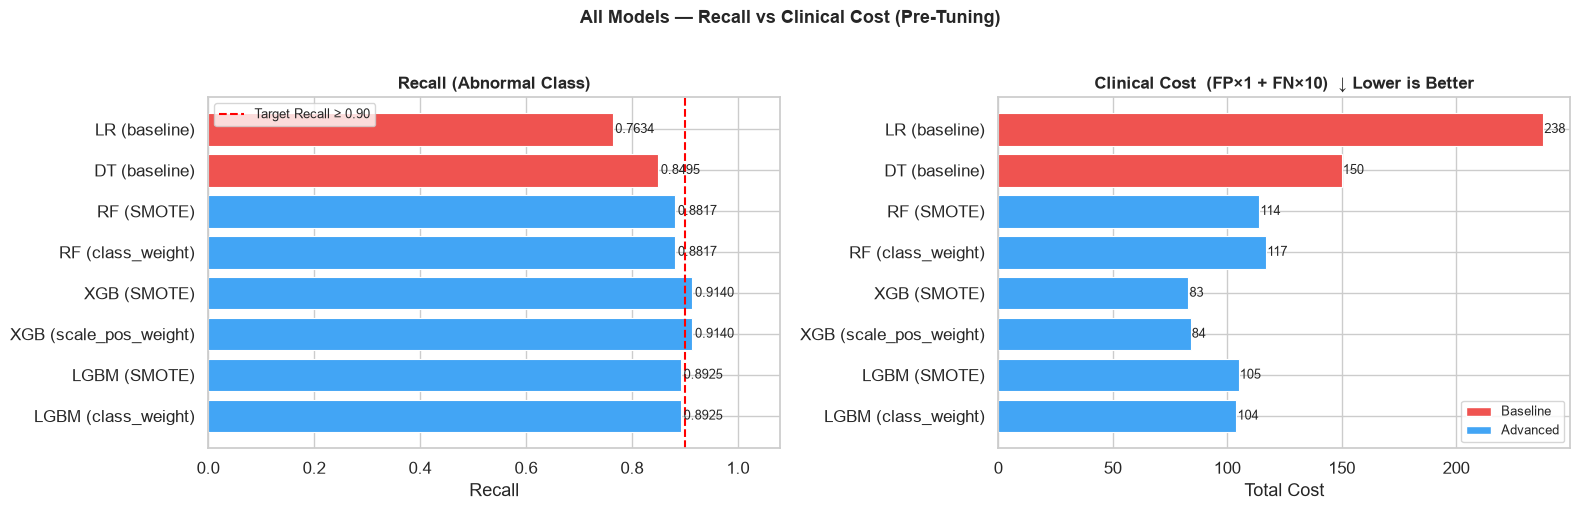

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Recall bar chart
models = df_metrics["Model"].tolist()
recalls = df_metrics["Recall"].tolist()
costs = df_metrics["Cost (FP+10×FN)"].tolist()
colors = ["#EF5350" if "baseline" in m else "#42A5F5" for m in models]

bars = axes[0].barh(models, recalls, color=colors, edgecolor="white", linewidth=0.8)
axes[0].axvline(
    0.9, color="red", linestyle="--", linewidth=1.5, label="Target Recall ≥ 0.90"
)
for bar, val in zip(bars, recalls):
    axes[0].text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center",
        fontsize=9,
    )
axes[0].set_xlim(0, 1.08)
axes[0].set_title("Recall (Abnormal Class)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Recall")
axes[0].legend(fontsize=9)
axes[0].invert_yaxis()

# Cost bar chart
bars2 = axes[1].barh(models, costs, color=colors, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars2, costs):
    axes[1].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va="center",
        fontsize=9,
    )
axes[1].set_title(
    "Clinical Cost  (FP×1 + FN×10)  ↓ Lower is Better", fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Total Cost")
axes[1].invert_yaxis()


legend_els = [
    Patch(facecolor="#EF5350", label="Baseline"),
    Patch(facecolor="#42A5F5", label="Advanced"),
]
axes[1].legend(handles=legend_els, fontsize=9)

plt.suptitle(
    "All Models — Recall vs Clinical Cost (Pre-Tuning)",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

---
## 7 · Hyperparameter Tuning with Optuna

**Objective:** minimise clinical cost `FP×1 + FN×10` via 5-fold cross-validation.

The scorer returns **negative cost** so Optuna (which maximises by default with
`direction='maximize'`) finds the lowest-cost configuration.

### 7a · Tune Random Forest (on SMOTE data)

In [16]:
def objective_rf(trial):
    """
    Optuna objective function for Random Forest hyperparameter tuning.
    Returns the mean cross-validated cost score (negated for maximization).
    """
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 25),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", None]
        ),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", None]),
        "random_state": SEED,
    }
    model = RandomForestClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = cross_val_score(
        model, X_train_smote, y_train_smote, cv=cv, scoring=custom_score, n_jobs=-1
    )
    return scores.mean()  # higher (less negative) = lower cost = better


study_rf = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_rf.optimize(objective_rf, n_trials=50, show_progress_bar=True)

print(
    f"\nBest CV cost score : {study_rf.best_value:.2f}  (negated; lower magnitude = better)"
)
print("Best parameters    :")
for k, v in study_rf.best_params.items():
    print(f"  {k:<22} : {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best CV cost score : 350.00  (negated; lower magnitude = better)
Best parameters    :
  n_estimators           : 371
  max_depth              : 3
  min_samples_split      : 19
  min_samples_leaf       : 9
  max_features           : sqrt
  class_weight           : None


### 7b · Tune XGBoost (on raw scaled data with scale_pos_weight)

In [17]:
def objective_xgb(trial):
    """
    Optuna objective function for XGBoost hyperparameter tuning.
    Returns the mean cross-validated cost score (negated for maximization).
    """
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 5.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 15.0),
        "eval_metric": "logloss",
        "verbosity": 0,
        "random_state": SEED,
    }
    model = xgb.XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = cross_val_score(
        model, X_train_scaled, y_train, cv=cv, scoring=custom_score, n_jobs=-1
    )
    return scores.mean()


study_xgb = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

print(f"\nBest CV cost score : {study_xgb.best_value:.2f}")
print("Best parameters    :")
for k, v in study_xgb.best_params.items():
    print(f"  {k:<22} : {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best CV cost score : 142.40
Best parameters    :
  n_estimators           : 351
  max_depth              : 6
  learning_rate          : 0.028921929983817544
  subsample              : 0.6208117899497801
  colsample_bytree       : 0.8560584150830376
  gamma                  : 3.9823544041686416
  reg_alpha              : 1.1469553045644358
  reg_lambda             : 3.1305200680311582
  scale_pos_weight       : 1.0225270598552967


### 7c · Tune LightGBM (on SMOTE data)

In [18]:
def objective_lgbm(trial):
    """
    Optuna objective function for LightGBM hyperparameter tuning.
    Returns the mean cross-validated cost score (negated for maximization).
    """
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", None]),
        "random_state": SEED,
        "verbose": -1,
    }
    model = lgb.LGBMClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = cross_val_score(
        cast(BaseEstimator, model), X_train_smote, y_train_smote, cv=cv, scoring=custom_score, n_jobs=-1
    )
    return scores.mean()


study_lgbm = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_lgbm.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)

print(f"\nBest CV cost score : {study_lgbm.best_value:.2f}")
print("Best parameters    :")
for k, v in study_lgbm.best_params.items():
    print(f"  {k:<22} : {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best CV cost score : 132.80
Best parameters    :
  n_estimators           : 68
  max_depth              : 7
  learning_rate          : 0.014911911668351669
  num_leaves             : 135
  subsample              : 0.8366849379399733
  colsample_bytree       : 0.999210869017396
  reg_alpha              : 0.8321421709230666
  reg_lambda             : 2.4950469032317515
  class_weight           : balanced


---
## 8 · Final Tuned Model Evaluation

In [19]:
# ── Fit tuned models on full training data ────────────────────────────────────
rf_best_params = {**study_rf.best_params, "random_state": SEED}
xgb_best_params = {
    **{k: v for k, v in study_xgb.best_params.items()},
    "eval_metric": "logloss",
    "verbosity": 0,
    "random_state": SEED,
}
lgbm_best_params = {**study_lgbm.best_params, "random_state": SEED, "verbose": -1}

tuned_rf = RandomForestClassifier(**rf_best_params)
tuned_xgb = xgb.XGBClassifier(**xgb_best_params)
tuned_lgbm = lgb.LGBMClassifier(**lgbm_best_params)

r_rf_tuned, tuned_rf_fit, pred_rf_tuned = evaluate_model(
    "RF (Tuned)", tuned_rf, X_train_smote, y_train_smote, X_test_scaled, y_test
)
r_xgb_tuned, tuned_xgb_fit, pred_xgb_tuned = evaluate_model(
    "XGB (Tuned)", tuned_xgb, X_train_scaled, y_train, X_test_scaled, y_test
)
r_lgbm_tuned, tuned_lgbm_fit, pred_lgbm_tuned = evaluate_model(
    "LGBM (Tuned)", tuned_lgbm, X_train_smote, y_train_smote, X_test_scaled, y_test
)

tuned_results = [r_rf_tuned, r_xgb_tuned, r_lgbm_tuned]
df_tuned = pd.DataFrame(tuned_results)

print("Tuned Model Results:")
print(
    df_tuned[
        ["Model", "Accuracy", "Precision", "Recall", "F1", "Cost (FP+10×FN)"]
    ].to_string(index=False)
)

Tuned Model Results:
       Model  Accuracy  Precision  Recall     F1  Cost (FP+10×FN)
  RF (Tuned)    0.9102     0.7670  0.8495 0.8061              164
 XGB (Tuned)    0.9527     0.9011  0.8817 0.8913              119
LGBM (Tuned)    0.9362     0.8300  0.8925 0.8601              117


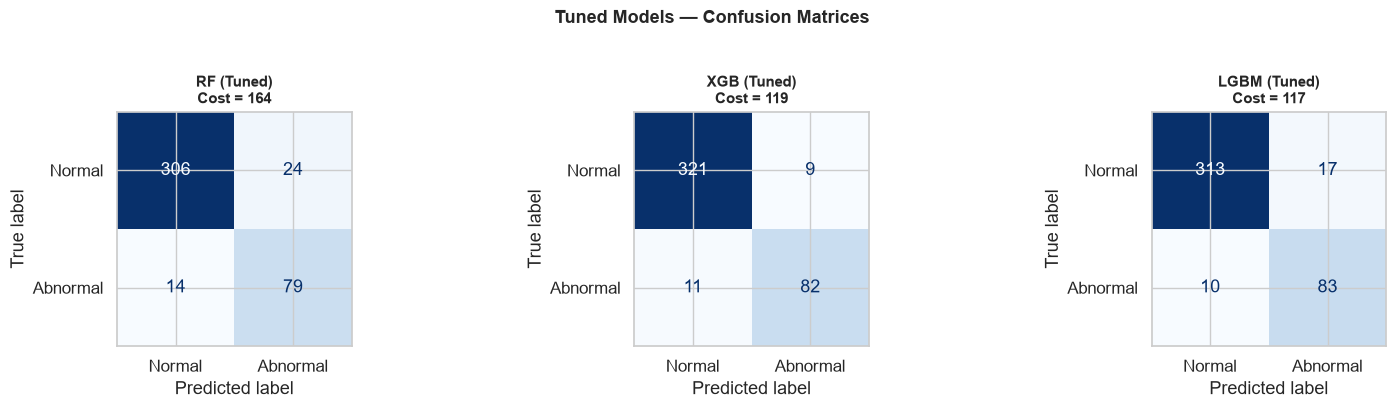

In [20]:
# ── Confusion matrices for all three tuned models ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, pred) in zip(
    axes,
    [
        ("RF (Tuned)", pred_rf_tuned),
        ("XGB (Tuned)", pred_xgb_tuned),
        ("LGBM (Tuned)", pred_lgbm_tuned),
    ],
):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Abnormal"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    cost = compute_cost(y_test, pred)
    ax.set_title(f"{name}\nCost = {cost}", fontsize=11, fontweight="bold")

plt.suptitle(
    "Tuned Models — Confusion Matrices", fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

---
## 9 · Full Model Comparison (All Models)

In [21]:
# Combine all pre-tuning + tuned results
df_final = pd.DataFrame(all_results + tuned_results)
df_final = df_final.sort_values("Cost (FP+10×FN)").reset_index(drop=True)
df_final["Rank"] = df_final["Cost (FP+10×FN)"].rank(method="min").astype(int)

display_cols = [
    "Rank",
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "TP",
    "FP",
    "TN",
    "FN",
    "Cost (FP+10×FN)",
]
print(df_final[display_cols].to_string(index=False))

 Rank                  Model  Accuracy  Precision  Recall     F1  TP  FP  TN  FN  Cost (FP+10×FN)
    1            XGB (SMOTE)    0.9740     0.9659  0.9140 0.9392  85   3 327   8               83
    2 XGB (scale_pos_weight)    0.9716     0.9551  0.9140 0.9341  85   4 326   8               84
    3    LGBM (class_weight)    0.9669     0.9540  0.8925 0.9222  83   4 326  10              104
    4           LGBM (SMOTE)    0.9645     0.9432  0.8925 0.9171  83   5 325  10              105
    5             RF (SMOTE)    0.9645     0.9535  0.8817 0.9162  82   4 326  11              114
    6      RF (class_weight)    0.9574     0.9213  0.8817 0.9011  82   7 323  11              117
    6           LGBM (Tuned)    0.9362     0.8300  0.8925 0.8601  83  17 313  10              117
    8            XGB (Tuned)    0.9527     0.9011  0.8817 0.8913  82   9 321  11              119
    9          DT (baseline)    0.9433     0.8876  0.8495 0.8681  79  10 320  14              150
   10             RF

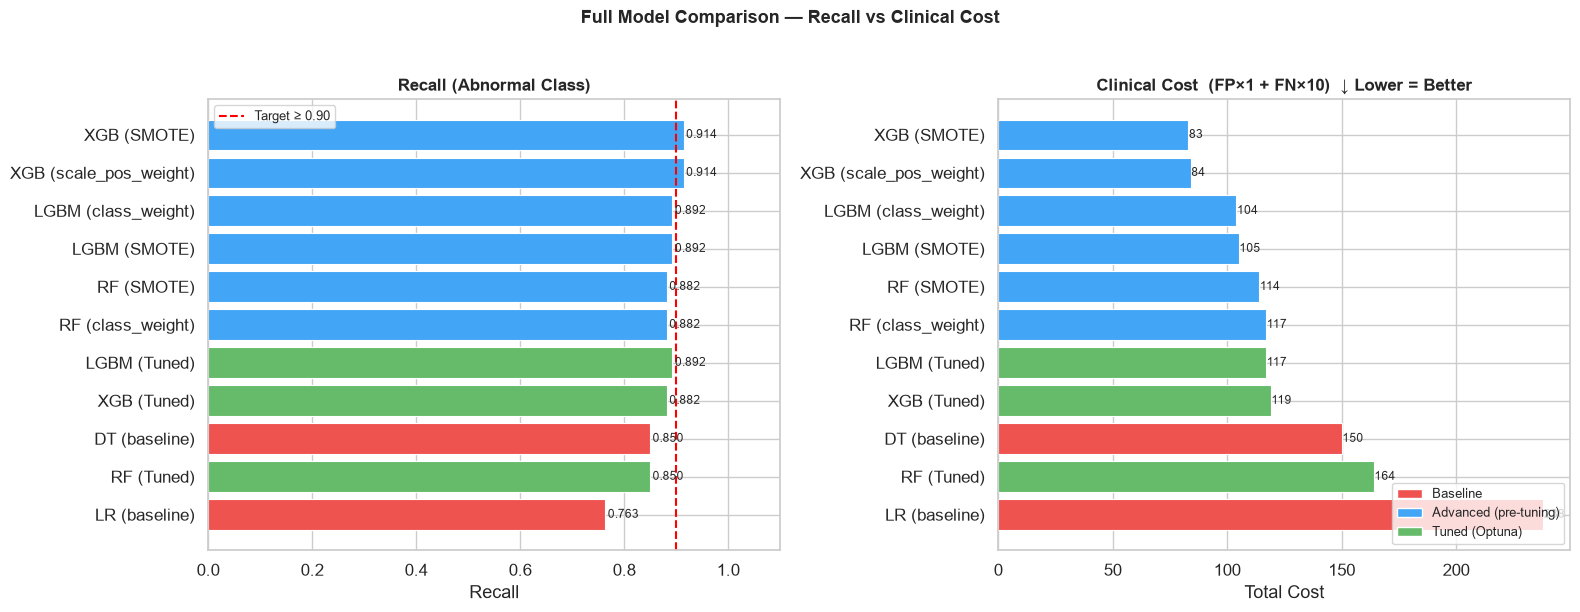

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette_bar = [
    "#EF5350" if "baseline" in m else "#66BB6A" if "Tuned" in m else "#42A5F5"
    for m in df_final["Model"]
]

# Recall
axes[0].barh(
    df_final["Model"],
    df_final["Recall"],
    color=palette_bar,
    edgecolor="white",
    linewidth=0.8,
)
axes[0].axvline(0.9, color="red", linestyle="--", linewidth=1.5, label="Target ≥ 0.90")
for i, (v, m) in enumerate(zip(df_final["Recall"], df_final["Model"])):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8.5)
axes[0].set_xlim(0, 1.1)
axes[0].set_title("Recall (Abnormal Class)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Recall")
axes[0].legend(fontsize=9)
axes[0].invert_yaxis()

# Cost
axes[1].barh(
    df_final["Model"],
    df_final["Cost (FP+10×FN)"],
    color=palette_bar,
    edgecolor="white",
    linewidth=0.8,
)
for i, v in enumerate(df_final["Cost (FP+10×FN)"]):
    axes[1].text(v + 0.3, i, str(v), va="center", fontsize=8.5)
axes[1].set_title(
    "Clinical Cost  (FP×1 + FN×10)  ↓ Lower = Better", fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Total Cost")
axes[1].invert_yaxis()



legend_els = [
    Patch(facecolor="#EF5350", label="Baseline"),
    Patch(facecolor="#42A5F5", label="Advanced (pre-tuning)"),
    Patch(facecolor="#66BB6A", label="Tuned (Optuna)"),
]
axes[1].legend(handles=legend_els, fontsize=9, loc="lower right")

plt.suptitle(
    "Full Model Comparison — Recall vs Clinical Cost",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

---
## 10 · Best Model & Optuna Optimisation History

In [23]:
best_row = df_final.iloc[0]
best_name = best_row["Model"]
print("=" * 60)
print(f"  🏆  Best Model : {best_name}")
print("=" * 60)
print(f"  Clinical Cost (FP×1 + FN×10) : {best_row['Cost (FP+10×FN)']}")
print(f"  Recall                         : {best_row['Recall']}")
print(f"  F1 Score                       : {best_row['F1']}")
print(f"  Accuracy                       : {best_row['Accuracy']}")
print(
    f"  TP: {best_row['TP']}  FP: {best_row['FP']}  TN: {best_row['TN']}  FN: {best_row['FN']}"
)
print("=" * 60)

  🏆  Best Model : XGB (SMOTE)
  Clinical Cost (FP×1 + FN×10) : 83
  Recall                         : 0.914
  F1 Score                       : 0.9392
  Accuracy                       : 0.974
  TP: 85  FP: 3  TN: 327  FN: 8


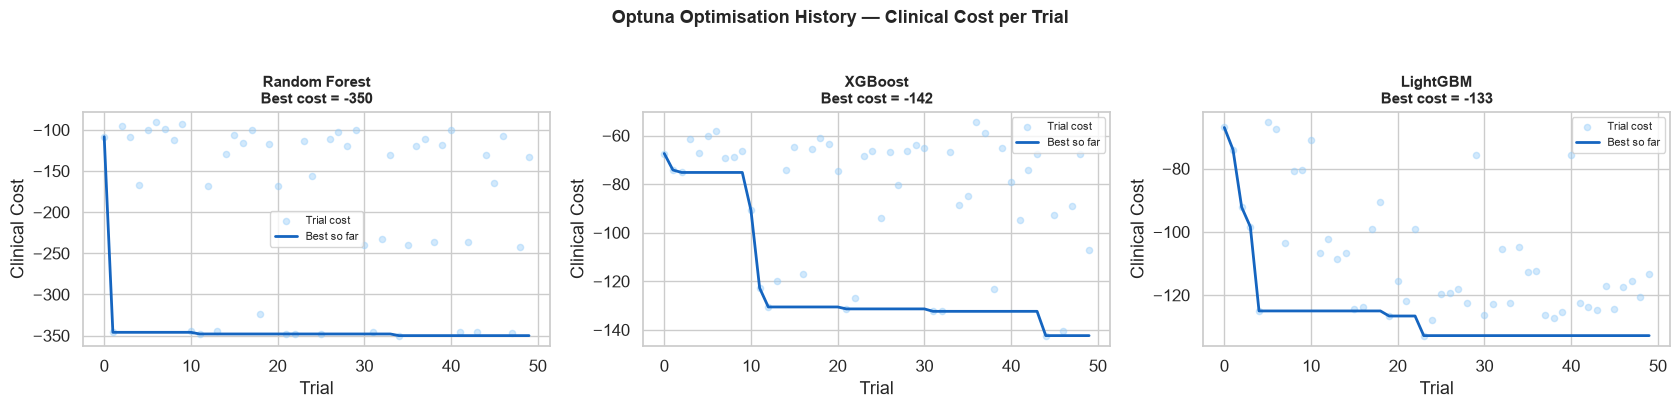

In [24]:
# Optuna optimisation history
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, (study, label) in zip(
    axes,
    [
        (study_rf, "Random Forest"),
        (study_xgb, "XGBoost"),
        (study_lgbm, "LightGBM"),
    ],
):
    trial_nums = [t.number for t in study.trials]
    # Running best (negate back to positive cost for display)
    values = [-t.value for t in study.trials]
    running_best = pd.Series(values).cummin().tolist()

    ax.scatter(trial_nums, values, alpha=0.4, s=20, color="#90CAF9", label="Trial cost")
    ax.plot(trial_nums, running_best, color="#1565C0", linewidth=2, label="Best so far")
    ax.set_title(
        f"{label}\nBest cost = {min(values):.0f}", fontsize=11, fontweight="bold"
    )
    ax.set_xlabel("Trial")
    ax.set_ylabel("Clinical Cost")
    ax.legend(fontsize=8)

plt.suptitle(
    "Optuna Optimisation History — Clinical Cost per Trial",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

---
## 11 · Phase 03 Summary

In [25]:
print("=" * 65)
print("  Phase 03 Summary — Cost-Sensitive Modeling")
print("=" * 65)
print()
print("  Cost Function : FP×1 + FN×10")
print("  Optimisation  : Optuna TPE, 50 trials each, 5-fold CV")
print()
print("  Pre-Tuning Baseline Range:")
baseline_costs = [r["Cost (FP+10×FN)"] for r in all_results if "baseline" in r["Model"]]
adv_costs = [r["Cost (FP+10×FN)"] for r in all_results if "baseline" not in r["Model"]]
tuned_costs = [r["Cost (FP+10×FN)"] for r in tuned_results]
print(
    f"    Baseline models  cost range : {min(baseline_costs)} – {max(baseline_costs)}"
)
print(f"    Advanced models  cost range : {min(adv_costs)} – {max(adv_costs)}")
print(f"    Tuned models     cost range : {min(tuned_costs)} – {max(tuned_costs)}")
print()
print(f"  🏆  Best Model  : {best_row['Model']}")
print(f"      Cost        : {best_row['Cost (FP+10×FN)']}")
print(f"      Recall      : {best_row['Recall']}")
print(f"      F1          : {best_row['F1']}")
print()
print("=" * 65)

  Phase 03 Summary — Cost-Sensitive Modeling

  Cost Function : FP×1 + FN×10
  Optimisation  : Optuna TPE, 50 trials each, 5-fold CV

  Pre-Tuning Baseline Range:
    Baseline models  cost range : 150 – 238
    Advanced models  cost range : 83 – 117
    Tuned models     cost range : 117 – 164

  🏆  Best Model  : XGB (SMOTE)
      Cost        : 83
      Recall      : 0.914
      F1          : 0.9392



---
## References

**Models**
- scikit-learn — `LogisticRegression`: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- scikit-learn — `DecisionTreeClassifier`: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
- scikit-learn — `RandomForestClassifier`: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
- Chen, T. & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. KDD '16. https://doi.org/10.1145/2939672.2939785
- XGBoost documentation — `scale_pos_weight` (imbalanced data guide): https://xgboost.readthedocs.io/en/stable/tutorials/param_tuning.html#handle-imbalanced-dataset
- Ke, G. et al. (2017). *LightGBM: A Highly Efficient Gradient Boosting Decision Tree*. NeurIPS 30. https://proceedings.neurips.cc/paper_files/paper/2017/file/6449f44a102fde848669bdd9eb6b76fa-Paper.pdf
- LightGBM documentation: https://lightgbm.readthedocs.io/

**Cost-Sensitive Learning & Custom Scoring**
- scikit-learn — `make_scorer`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html
- scikit-learn — `confusion_matrix`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
- Elkan, C. (2001). *The Foundations of Cost-Sensitive Learning*. IJCAI, 973-978. https://cseweb.ucsd.edu/~elkan/rescale.pdf (author's own hosted copy, UCSD)

**Hyperparameter Tuning**
- Akiba, T. et al. (2019). *Optuna: A Next-generation Hyperparameter Optimization Framework*. KDD '19. https://doi.org/10.1145/3292500.3330701
- Optuna documentation: https://optuna.readthedocs.io/
- scikit-learn — `GridSearchCV`: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
- scikit-learn — `StratifiedKFold`: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html
